# Phylum and Class Distribution

This notebook summarizes how the records in `EDA/Dataset.csv` are distributed across the `taxon_phylum` and `taxon_class` labels and quantifies their frequencies.

In [46]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

dataset_path = None
for candidate in (
    Path('Dataset.csv'),
    Path('EDA/Dataset.csv'),
):
    if candidate.exists():
        dataset_path = candidate
        break
if dataset_path is None:
    raise FileNotFoundError('Dataset.csv not found; run the phylum sampling cell first.')

df = pd.read_csv(dataset_path)

print(
    f'Read {len(df):,} rows and {len(df.columns)} columns from {dataset_path}.',
)
df.head(3)

Read 24,807 rows and 22 columns from Dataset.csv.


,observation_id,photo_id,license_code,square_url,medium_url,large_url,original_url,scientific_name,common_name,taxon_rank,...,uri,pred_prey,special_type_of_feeding,taxon_kingdom,taxon_phylum,taxon_class,taxon_order,taxon_family,taxon_genus,taxon_species
0,341194952,621071156,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,Ardea alba,Great Egret,species,...,https://www.inaturalist.org/observations/34119...,Pred,Predation,Animalia,Chordata,Aves,Pelecaniformes,Ardeidae,Ardea,Ardea alba
1,341194952,621071168,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,Ardea alba,Great Egret,species,...,https://www.inaturalist.org/observations/34119...,Pred,Predation,Animalia,Chordata,Aves,Pelecaniformes,Ardeidae,Ardea,Ardea alba
2,341194952,621071177,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,Ardea alba,Great Egret,species,...,https://www.inaturalist.org/observations/34119...,Pred,Predation,Animalia,Chordata,Aves,Pelecaniformes,Ardeidae,Ardea,Ardea alba


## Phylum counts

Compute the number and percentage of observations that fall into each phylum.

In [47]:
phylum_counts = (
    df['taxon_phylum']
    .fillna('Unknown')
    .astype(str)
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'phylum'})
)
phylum_counts['percent'] = 100 * phylum_counts['count'] / len(df)
phylum_counts

,taxon_phylum,count,percent
0,Chordata,11272,45.438787
1,Arthropoda,8579,34.582981
2,Tracheophyta,4137,16.676744
3,Ascomycota,356,1.435079
4,Mollusca,189,0.761882
5,Basidiomycota,88,0.354739
6,Echinodermata,52,0.209618
7,Onychophora,38,0.153183
8,Cnidaria,27,0.108840
9,Platyhelminthes,19,0.076591


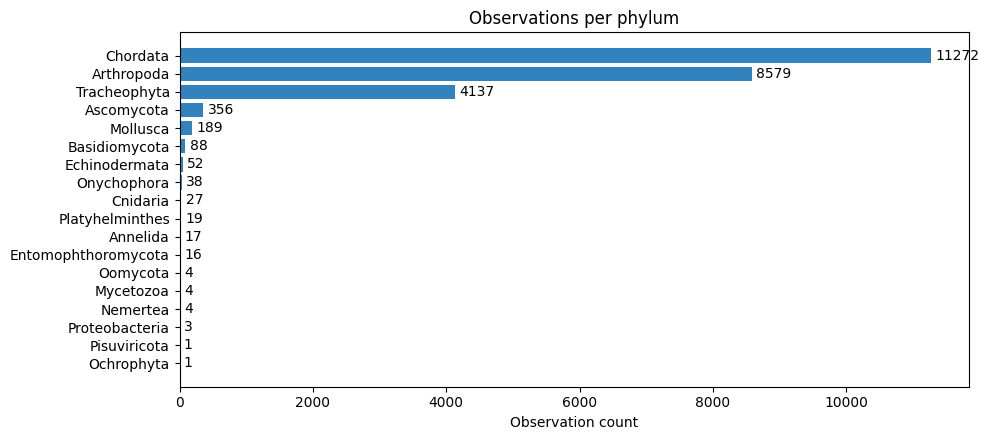

In [48]:
fig, ax = plt.subplots(figsize=(10, max(4, len(phylum_counts) * 0.25)))
bars = ax.barh(phylum_counts['taxon_phylum'], phylum_counts['count'], color='#3182bd')
ax.set_xlabel('Observation count')
ax.set_title('Observations per phylum')
ax.invert_yaxis()
ax.bar_label(bars, fmt='%d', padding=3)
plt.tight_layout()
# fig

## Class counts

Repeat the same analysis for the `taxon_class` values.

In [49]:
class_counts = (
    df['taxon_class']
    .fillna('Unknown')
    .astype(str)
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'taxon_class'})
)
class_counts['percent'] = 100 * class_counts['count'] / len(df)
class_counts

,taxon_class,count,percent
0,Aves,7406,29.854477
1,Insecta,6588,26.557020
2,Magnoliopsida,3908,15.753618
3,Arachnida,1693,6.824687
4,Mammalia,1470,5.925747
5,Reptilia,1343,5.413794
6,Actinopterygii,750,3.023340
7,Dothideomycetes,285,1.148869
8,Amphibia,273,1.100496
9,Liliopsida,213,0.858629


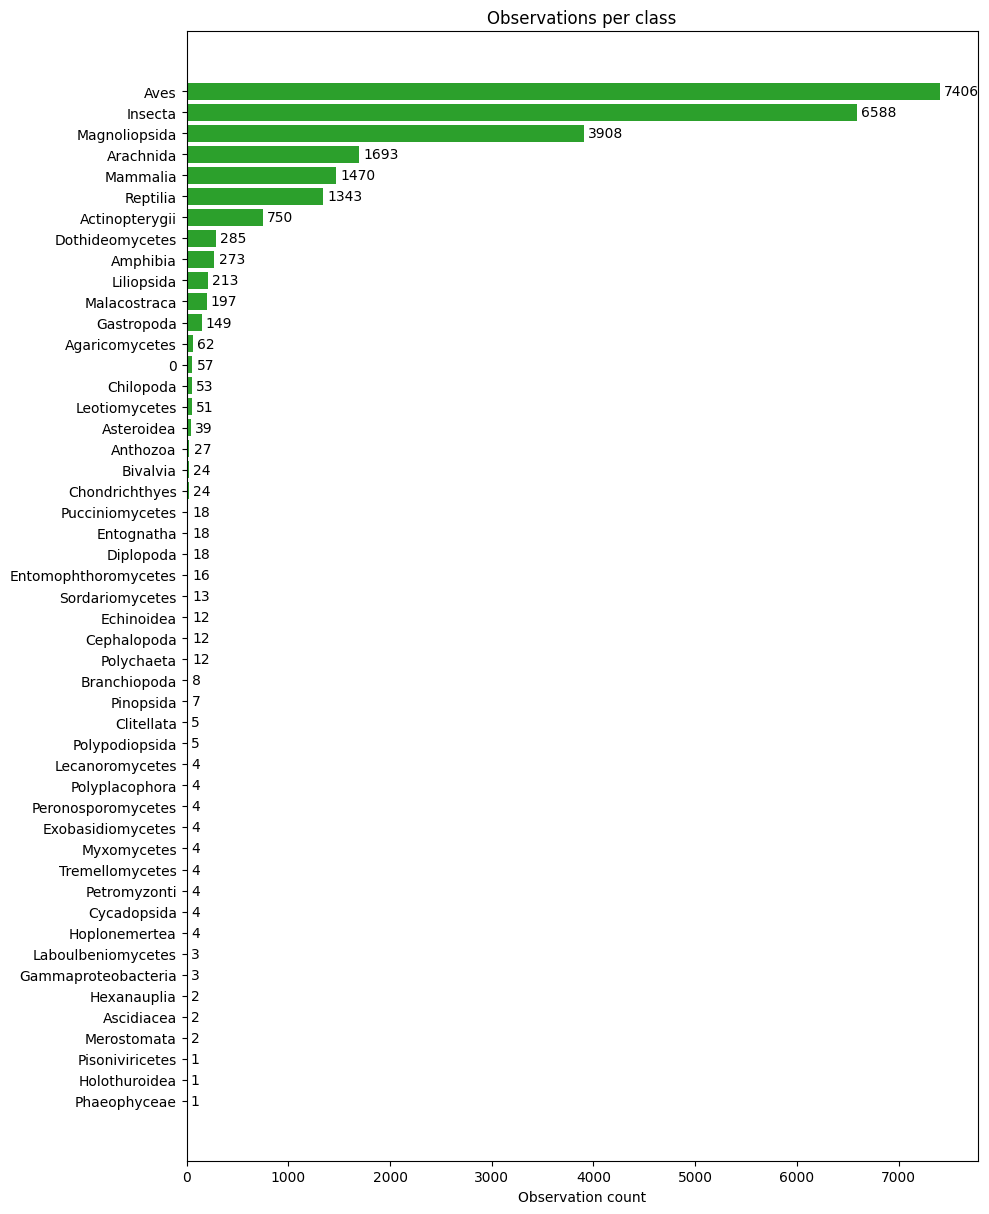

In [50]:
fig, ax = plt.subplots(figsize=(10, max(4, len(class_counts) * 0.25)))
bars = ax.barh(class_counts['taxon_class'], class_counts['count'], color='#2ca02c')
ax.set_xlabel('Observation count')
ax.set_title('Observations per class')
ax.invert_yaxis()
ax.bar_label(bars, fmt='%d', padding=3)
plt.tight_layout()
# fig

## Chordata diversity samples

Find up to seven observations from the Chordata phylum that each have a unique combination of class, order, family, and genus.

In [51]:
from pathlib import Path
phylum_cols = ['taxon_class', 'taxon_order', 'taxon_family', 'taxon_genus']
phylum_samples = []
for phylum in sorted(df['taxon_phylum'].dropna().unique()):
    phylum_df = df[df['taxon_phylum'] == phylum] 
    phylum_unique = (
        phylum_df
        .drop_duplicates(subset=phylum_cols)
        .head(7)
        .reset_index(drop=True)
    )
    phylum_samples.append(phylum_unique)
    print(
        f"Showing {len(phylum_unique)} {phylum} entries with distinct class/order/family/genus combos (up to 7)."
    )
phylum_samples_df = pd.concat(phylum_samples, ignore_index=True)
output_path = Path('phylum_samples.csv')
output_path.parent.mkdir(exist_ok=True)
phylum_samples_df.to_csv(output_path, index=False)
phylum_samples_df


Showing 4 Annelida entries with distinct class/order/family/genus combos (up to 7).
Showing 7 Arthropoda entries with distinct class/order/family/genus combos (up to 7).
Showing 7 Ascomycota entries with distinct class/order/family/genus combos (up to 7).
Showing 7 Basidiomycota entries with distinct class/order/family/genus combos (up to 7).
Showing 7 Chordata entries with distinct class/order/family/genus combos (up to 7).
Showing 2 Cnidaria entries with distinct class/order/family/genus combos (up to 7).
Showing 6 Echinodermata entries with distinct class/order/family/genus combos (up to 7).
Showing 3 Entomophthoromycota entries with distinct class/order/family/genus combos (up to 7).
Showing 7 Mollusca entries with distinct class/order/family/genus combos (up to 7).
Showing 1 Mycetozoa entries with distinct class/order/family/genus combos (up to 7).
Showing 1 Nemertea entries with distinct class/order/family/genus combos (up to 7).
Showing 1 Ochrophyta entries with distinct class/o

,observation_id,photo_id,license_code,square_url,medium_url,large_url,original_url,scientific_name,common_name,taxon_rank,...,uri,pred_prey,special_type_of_feeding,taxon_kingdom,taxon_phylum,taxon_class,taxon_order,taxon_family,taxon_genus,taxon_species
0,340304697,619256274,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,Haemopis grandis,0,species,...,https://www.inaturalist.org/observations/34030...,Pred,Predation,Animalia,Annelida,Clitellata,Arhynchobdellida,Haemopidae,Haemopis,Haemopis grandis
1,130480768,70327211,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,Hirudo michaelseni,Common African Leech,species,...,https://www.inaturalist.org/observations/13048...,Pred,Parasitism,Animalia,Annelida,Clitellata,Arhynchobdellida,Hirudinidae,Hirudo,Hirudo michaelseni
2,108694744,183053796,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,Urechis caupo,Fat Innkeeper Worm,species,...,https://www.inaturalist.org/observations/10869...,Prey,Predation,Animalia,Annelida,Polychaeta,Echiuroidea,Urechidae,Urechis,Urechis caupo
3,64497720,103704678,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,Alitta williami,0,species,...,https://www.inaturalist.org/observations/64497720,Prey,Predation,Animalia,Annelida,Polychaeta,Phyllodocida,Nereididae,Alitta,Alitta williami
4,341067936,620805844,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,Apis mellifera,Western Honey Bee,species,...,https://www.inaturalist.org/observations/34106...,Pred,Pollination,Animalia,Arthropoda,Insecta,Hymenoptera,Apidae,Apis,Apis mellifera
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,340337865,533753896,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,Vicia cracca,tufted vetch,species,...,https://www.inaturalist.org/observations/34033...,Prey,Pollination,Plantae,Tracheophyta,Magnoliopsida,Fabales,Fabaceae,Vicia,Vicia cracca
66,340337296,536341964,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,Lotus corniculatus,bird's-foot trefoil,species,...,https://www.inaturalist.org/observations/34033...,Prey,Pollination,Plantae,Tracheophyta,Magnoliopsida,Fabales,Fabaceae,Lotus,Lotus corniculatus
67,340326193,619295159,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,Diospyros virginiana,American persimmon,species,...,https://www.inaturalist.org/observations/34032...,Prey,Parasitism,Plantae,Tracheophyta,Magnoliopsida,Ericales,Ebenaceae,Diospyros,Diospyros virginiana
68,340271186,619190124,cc0,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,Baccharis pilularis,coyote brush,species,...,https://www.inaturalist.org/observations/34027...,Pr

## New dataset count distribution

In [69]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

dataset_path = None
for candidate in (
    Path('phylum_samples.csv'),
    Path('EDA/phylum_samples.csv'),
):
    if candidate.exists():
        dataset_path = candidate
        break
if dataset_path is None:
    raise FileNotFoundError('outputs/phylum_samples.csv not found; run the phylum sampling cell first.')

df = pd.read_csv(dataset_path)

print(
    f'Read {len(df):,} rows and {len(df.columns)} columns from {dataset_path}.',
)
df.head(3)

Read 63 rows and 27 columns from phylum_samples.csv.


,observation_id,photo_id,Image_name,GroundingDino_V.1_Detected?,V.1 Analysis,GroundingDino_V.2_Detected?,V.2 Analysis,license_code,square_url,medium_url,...,uri,pred_prey,special_type_of_feeding,taxon_kingdom,taxon_phylum,taxon_class,taxon_order,taxon_family,taxon_genus,taxon_species
0,102691691,171703626,obs_102691691_photo_171703626,Maybe,Tiny part of the box,Yes,Visible,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,...,https://www.inaturalist.org/observations/10269...,Prey,Predation,Chromista,Ochrophyta,Phaeophyceae,Laminariales,Lessoniaceae,Egregia,Egregia menziesii
1,10317797,14298032,obs_10317797_photo_14298032,Maybe,Tiny part of the box,Yes,Visible,cc-by-nc,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,...,https://www.inaturalist.org/observations/10317797,Prey,Predation,Animalia,Echinodermata,Asteroidea,Valvatida,Asteropseidae,Dermasterias,Dermasterias imbricata
2,130480768,70327211,obs_130480768_photo_70327211,Maybe,Tiny part of the box,Yes,Visible,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,...,https://www.inaturalist.org/observations/13048...,Pred,Parasitism,Animalia,Annelida,Clitellata,Arhynchobdellida,Hirudinidae,Hirudo,Hirudo michaelseni


In [53]:
phylum_counts = (
    df['taxon_phylum']
    .fillna('Unknown')
    .astype(str)
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'phylum'})
)
phylum_counts['percent'] = 100 * phylum_counts['count'] / len(df)
phylum_counts

,taxon_phylum,count,percent
0,Basidiomycota,7,11.111111
1,Ascomycota,7,11.111111
2,Echinodermata,6,9.523810
3,Mollusca,6,9.523810
4,Tracheophyta,6,9.523810
5,Arthropoda,6,9.523810
6,Chordata,6,9.523810
7,Annelida,3,4.761905
8,Platyhelminthes,3,4.761905
9,Onychophora,3,4.761905


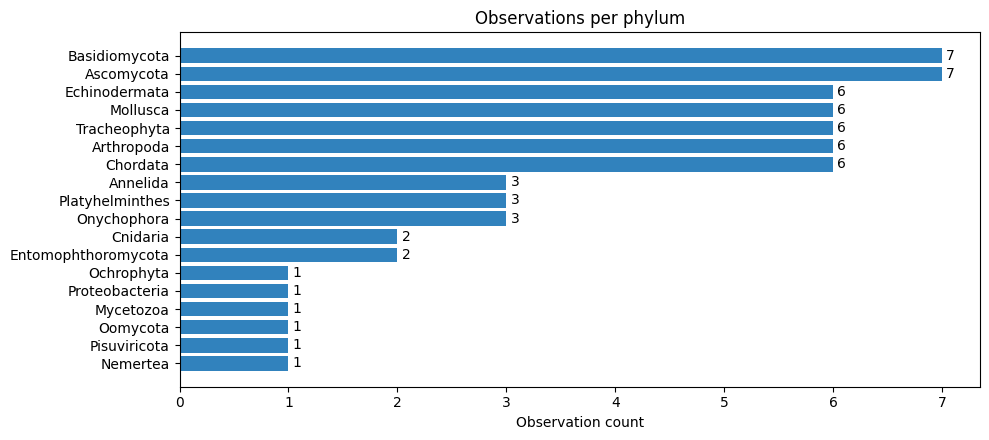

In [54]:
fig, ax = plt.subplots(figsize=(10, max(4, len(phylum_counts) * 0.25)))
bars = ax.barh(phylum_counts['taxon_phylum'], phylum_counts['count'], color='#3182bd')
ax.set_xlabel('Observation count')
ax.set_title('Observations per phylum')
ax.invert_yaxis()
ax.bar_label(bars, fmt='%d', padding=3)
plt.tight_layout()
# fig


In [44]:
class_counts = (
    df['taxon_class']
    .fillna('Unknown')
    .astype(str)
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'taxon_class'})
)
class_counts['percent'] = 100 * class_counts['count'] / len(df)
class_counts

,taxon_class,count,percent
0,0,6,9.523810
1,Magnoliopsida,6,9.523810
2,Insecta,6,9.523810
3,Agaricomycetes,4,6.349206
4,Gastropoda,4,6.349206
5,Aves,4,6.349206
6,Asteroidea,3,4.761905
7,Pucciniomycetes,3,4.761905
8,Dothideomycetes,3,4.761905
9,Leotiomycetes,3,4.761905


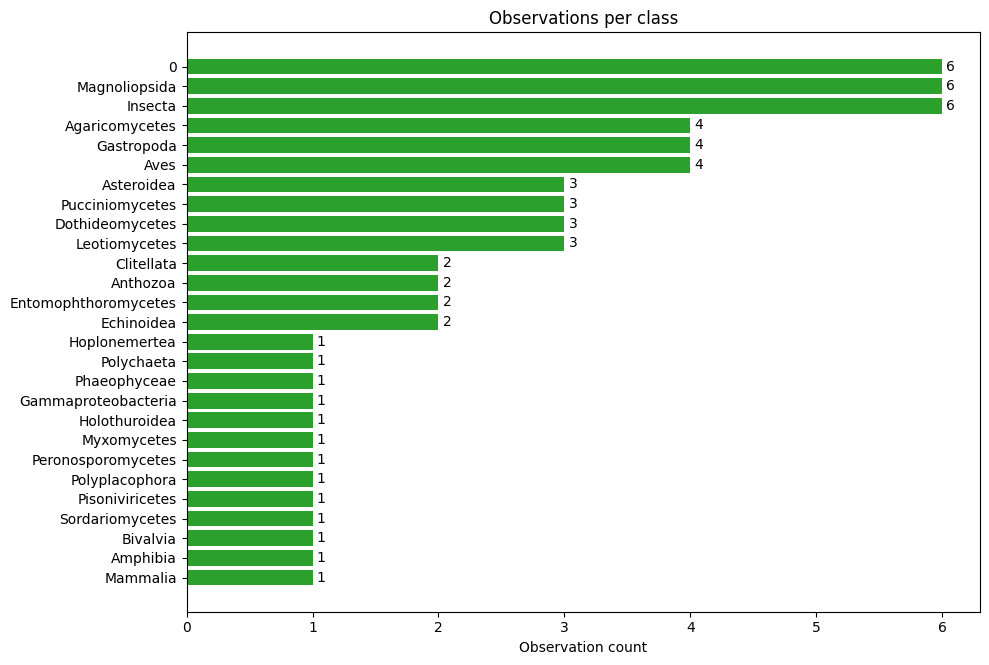

In [45]:
fig, ax = plt.subplots(figsize=(10, max(4, len(class_counts) * 0.25)))
bars = ax.barh(class_counts['taxon_class'], class_counts['count'], color='#2ca02c')
ax.set_xlabel('Observation count')
ax.set_title('Observations per class')
ax.invert_yaxis()
ax.bar_label(bars, fmt='%d', padding=3)
plt.tight_layout()
# fig

# Distribution of analysis for groundingDino v.1

In [72]:
v1_counts = (
    df['GroundingDino_V.1_Detected?']
    .fillna('Unknown')
    .astype(str)
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'v1_detected'})
)
v1_counts['percent'] = 100 * v1_counts['count'] / len(df)
v1_counts

,GroundingDino_V.1_Detected?,count,percent
0,Yes,40,63.492063
1,Maybe,23,36.507937


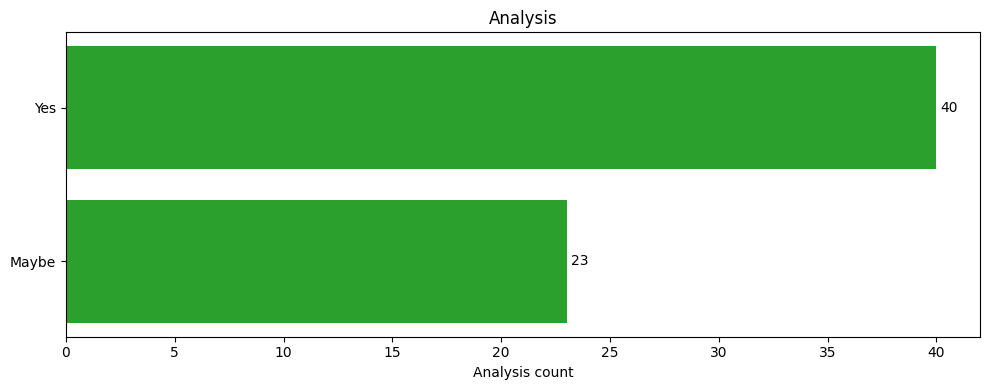

In [74]:
fig, ax = plt.subplots(figsize=(10, max(4, len(v1_counts) * 0.25)))
bars = ax.barh(v1_counts['GroundingDino_V.1_Detected?'], v1_counts['count'], color='#2ca02c')
ax.set_xlabel('Analysis count')
ax.set_title('Analysis')
ax.invert_yaxis()
ax.bar_label(bars, fmt='%d', padding=3)
plt.tight_layout()
# fig

# Distribution of analysis for groundingDino v.2

In [75]:
v2_counts = (
    df['GroundingDino_V.2_Detected?']
    .fillna('Unknown')
    .astype(str)
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'v1=2_detected'})
)
v2_counts['percent'] = 100 * v2_counts['count'] / len(df)
v2_counts

,GroundingDino_V.2_Detected?,count,percent
0,Yes,53,84.126984
1,Maybe,10,15.873016


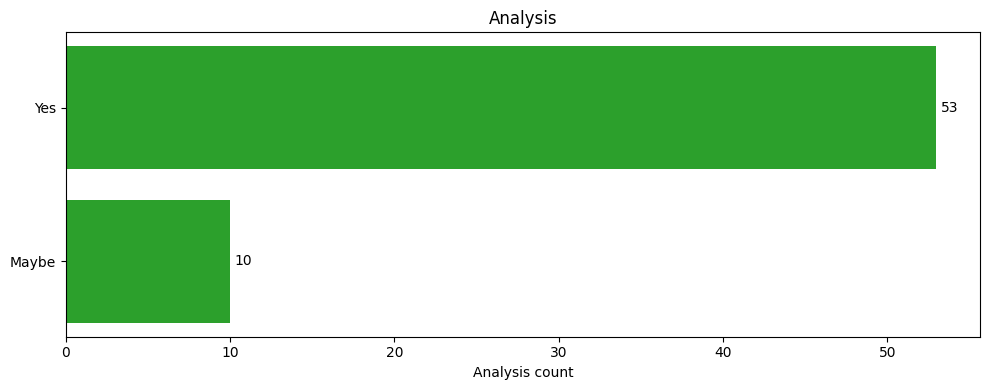

In [77]:
fig, ax = plt.subplots(figsize=(10, max(4, len(v2_counts) * 0.25)))
bars = ax.barh(v2_counts['GroundingDino_V.2_Detected?'], v2_counts['count'], color='#2ca02c')
ax.set_xlabel('Analysis count')
ax.set_title('Analysis')
ax.invert_yaxis()
ax.bar_label(bars, fmt='%d', padding=3)
plt.tight_layout()
# fig

In [79]:
#How many percent improvement in yes from v1 to v2?
v2_percent = v2_counts.loc[v2_counts['GroundingDino_V.2_Detected?'] == 'Yes', 'percent'].iloc[0]
v1_percent = v1_counts.loc[v1_counts['GroundingDino_V.1_Detected?'] == 'Yes', 'percent'].iloc[0]
percent_improvement = v2_percent - v1_percent
percent_improvement

np.float64(20.634920634920633)

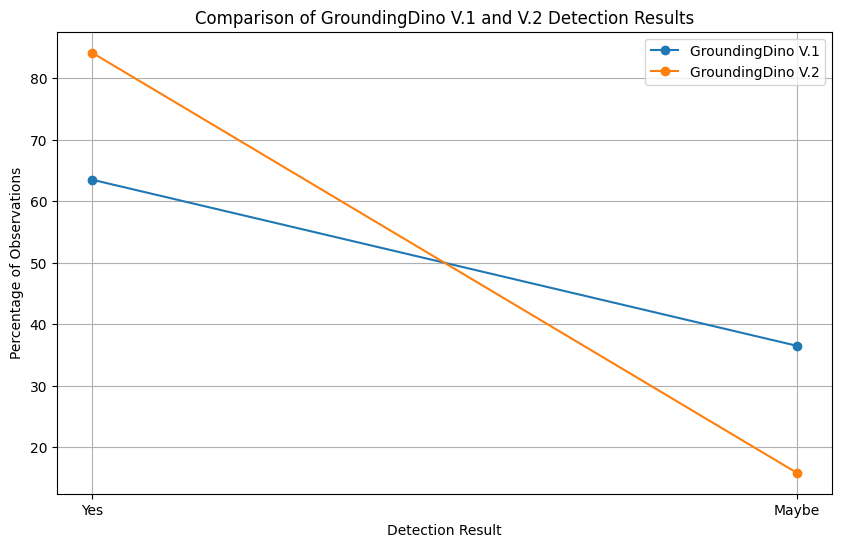

In [80]:
# Plot both v1 and v2 in a line graph for comparison
plt.figure(figsize=(10, 6))
plt.plot(v1_counts['GroundingDino_V.1_Detected?'], v1_counts['percent'], marker='o', label='GroundingDino V.1')
plt.plot(v2_counts['GroundingDino_V.2_Detected?'], v2_counts['percent'], marker='o', label='GroundingDino V.2')
plt.xlabel('Detection Result')
plt.ylabel('Percentage of Observations')
plt.title('Comparison of GroundingDino V.1 and V.2 Detection Results')
plt.legend()
plt.grid()


# Analysis DISTRIBUTION

In [10]:
import pandas as pd

df = pd.read_csv("phylum_samples.csv")

label_col = "crop+bioclip classification v.4"
analysis_col = "v.4 Analysis"


In [11]:

# Overall stats
total = len(df)
false_df = df[df[label_col].astype(str).str.lower() == "false"].copy()
true_df = df[df[label_col].astype(str).str.lower() == "true"].copy()
print("Total:", total)
print("True:", len(true_df))
print("False:", len(false_df))
print("Accuracy:", round(len(true_df) / total * 100, 2), "%")

Total: 63
True: 36
False: 27
Accuracy: 57.14 %


In [12]:



# Exact analysis breakdown
stats = false_df[analysis_col].value_counts(dropna=False).reset_index()
stats.columns = ["Analysis", "Count"]
stats["% of false"] = (stats["Count"] / len(false_df) * 100).round(2)
stats["% of total"] = (stats["Count"] / total * 100).round(2)

print("\nExact analysis breakdown:")
print(stats)



Exact analysis breakdown:
                                            Analysis  Count  % of false  \
0           Same taxon genus but wrong species level      8       29.63   
1           Species is small part of the box. Fungus      7       25.93   
2                    Species features not very clear      3       11.11   
3                   Species is small part of the box      3       11.11   
4  Species is small part of the box; Species feat...      2        7.41   
5                 Misidentified as different species      2        7.41   
6                             Species not in the box      2        7.41   

   % of total  
0       12.70  
1       11.11  
2        4.76  
3        4.76  
4        3.17  
5        3.17  
6        3.17  


In [15]:
group_mapping = {
    "Group 1: Same taxon genus but wrong species level": [
        "Same taxon genus but wrong species level"
    ],
    "Group 2: Species is small part of the box": [
        "Species is small part of the box",
        "Species is small part of the box. Fungus."
    ],
    "Group 3: Species features not very clear": [
        "Species features not very clear",
        "Species is small part of the box; Species features not very clear",
        "Species is small part of the box. Fungus; Species features not very clear"
    ],
    "Group 4: Misidentified as different species": [
        "Misidentified as different species"
    ],
    "Group 5: Species not in the box": [
        "Species not in the box"
    ]
}

# -----------------------------
# 3. Compute grouped stats
# -----------------------------
rows = []

for group_name, notes in group_mapping.items():
    count = false_df[false_df[analysis_col].isin(notes)].shape[0]
    
    rows.append({
        "Group": group_name,
        "Count": count,
        "% of false": round((count / len(false_df)) * 100, 2) if len(false_df) else 0,
        "% of total": round((count / total) * 100, 2) if total else 0
    })

grouped_stats = pd.DataFrame(rows)

print(grouped_stats)

                                               Group  Count  % of false  \
0  Group 1: Same taxon genus but wrong species level      8       29.63   
1          Group 2: Species is small part of the box      3       11.11   
2           Group 3: Species features not very clear      5       18.52   
3        Group 4: Misidentified as different species      2        7.41   
4                    Group 5: Species not in the box      2        7.41   

   % of total  
0       12.70  
1        4.76  
2        7.94  
3        3.17  
4        3.17  
